In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

data1= pd.read_csv("accidents_2005_to_2007.csv")
data2= pd.read_csv("accidents_2009_to_2011.csv")
data3= pd.read_csv("accidents_2012_to_2014.csv")
dataTotal= pd.concat([data1,data2,data3],ignore_index=True) # combine data
df = dataTotal.copy()
df.head()

,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,04/01/2005,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,05/01/2005,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,06/01/2005,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,07/01/2005,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,10/01/2005,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


In [32]:
# Eksik Veri Analizi

missing_values = df.isnull().sum() # calculate missing values count

print("\nMissing Values Count: \n")
print(missing_values)


Missing Values Count: 

Accident_Index                                       0
Location_Easting_OSGR                              101
Location_Northing_OSGR                             101
Longitude                                          101
Latitude                                           101
Police_Force                                         0
Accident_Severity                                    0
Number_of_Vehicles                                   0
Number_of_Casualties                                 0
Date                                                 0
Day_of_Week                                          0
Time                                               117
Local_Authority_(District)                           0
Local_Authority_(Highway)                            0
1st_Road_Class                                       0
1st_Road_Number                                      0
Road_Type                                            0
Speed_limit                             

In [33]:
# Eksik Veri Temizleme İşlemleri

# delete too many missing value rows
columns_to_drop = [
    'Junction_Detail',
    'Junction_Control',
    'Special_Conditions_at_Site',
    'Carriageway_Hazards'
]
df.drop(columns=columns_to_drop, axis=1, inplace=True)

# fill the Time values to "00:00"
df['Time'].fillna('00:00', inplace=True)

# fill the Weather_Conditions column with the most common value
most_common_weather = df['Weather_Conditions'].mode()[0]
df['Weather_Conditions'].fillna(most_common_weather, inplace=True)

# fill the Road_Surface_Conditions column with the most common value
most_common_surface = df['Road_Surface_Conditions'].mode()[0]
df['Road_Surface_Conditions'].fillna(most_common_surface, inplace=True)

# fill the Pedestrian_Crossing-Human_Control column with the None value
df['Pedestrian_Crossing-Human_Control'].fillna("None", inplace=True)

# fill the Pedestrian_Crossing-Physical_Facilities column with the "No crossing" value
df['Pedestrian_Crossing-Physical_Facilities'].fillna("No crossing", inplace=True)

# fill the Did_Police_Officer_Attend_Scene_of_Accident column with the "Unknown" value
df['Did_Police_Officer_Attend_Scene_of_Accident'].fillna("Unknown", inplace=True)


print("\nKalan Eksik Veriler:")
print(df.isnull().sum()[df.isnull().sum() > 0])



Kalan Eksik Veriler:
Location_Easting_OSGR           101
Location_Northing_OSGR          101
Longitude                       101
Latitude                        101
LSOA_of_Accident_Location    108238
dtype: int64


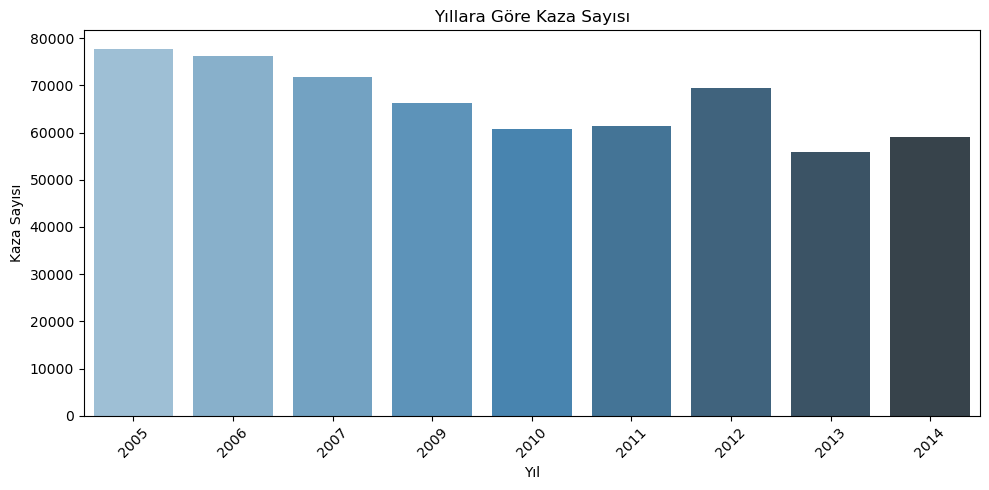

In [49]:
# Yıllık Kaza Analizi

df['Date'] = pd.to_datetime(df['Date'], errors='coerce') # convert date to datetime format

df['Year'] = df['Year'].dropna().astype(int) # remove Nan values set to int type

accident_count = df['Year'].value_counts().sort_index() # calculate accident count by yearly

plt.figure(figsize=(10, 5))
bars = sns.barplot(x=accident_count.index, y=accident_count.values, palette="Blues_d")


plt.xticks(  # set axis labels to string
    ticks=range(len(accident_count.index)),
    labels=[str(int(y)) for y in accident_count.index], 
    rotation=45
)

plt.title("Yıllara Göre Kaza Sayısı")
plt.xlabel("Yıl")
plt.ylabel("Kaza Sayısı")
plt.tight_layout()
plt.show()

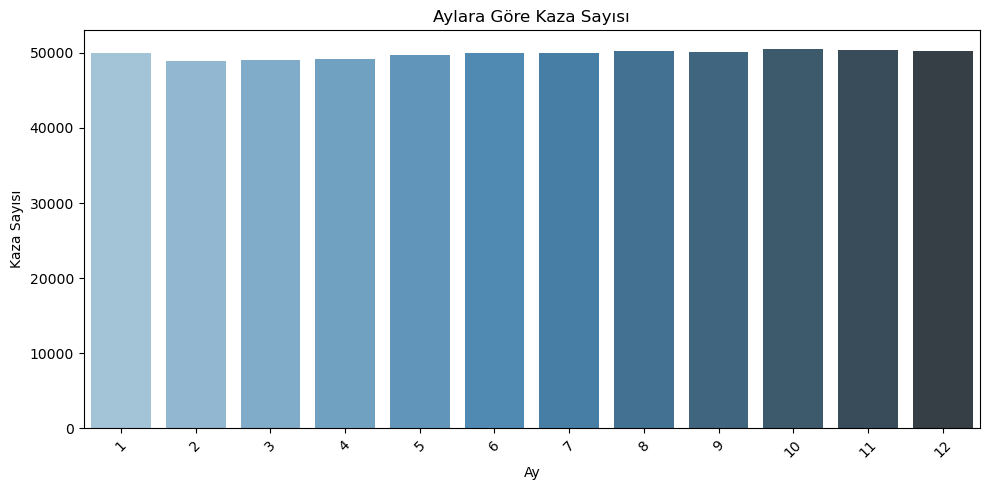

In [50]:
# Aylık Kaza Analizi

df['Date'] = pd.to_datetime(df['Date'], errors='coerce') # convert date to datetime format

df['Month'] = df['Date'].dt.month # remove Nan values set to int type

accident_count = df['Month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = sns.barplot(x=accident_count.index, y=accident_count.values, palette="Blues_d")


plt.xticks(  # set axis labels to string
    ticks=range(len(accident_count.index)),
    labels=[str(int(y)) for y in accident_count.index], 
    rotation=45
)

plt.title("Aylara Göre Kaza Sayısı")
plt.xlabel("Ay")
plt.ylabel("Kaza Sayısı")
plt.tight_layout()
plt.show()

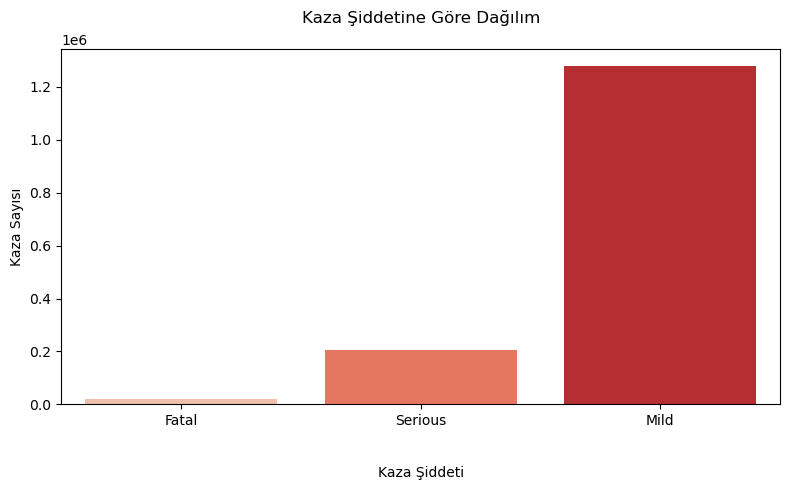

In [54]:
# Kazaların şiddetlerine göre dağılım grafik Analizi

count = df['Accident_Severity'].value_counts().sort_index() # count the values

labels = {
    1: 'Fatal',
    2: 'Serious',
    3: 'Mild'
}

count.index = [labels[i] for i in count.index]

plt.figure(figsize=(8, 5))
sns.barplot(x=count.index, y=count.values, palette="Reds")

plt.title("Kaza Şiddetine Göre Dağılım\n")
plt.xlabel("\n\nKaza Şiddeti")
plt.ylabel("Kaza Sayısı")
plt.tight_layout()
plt.show()


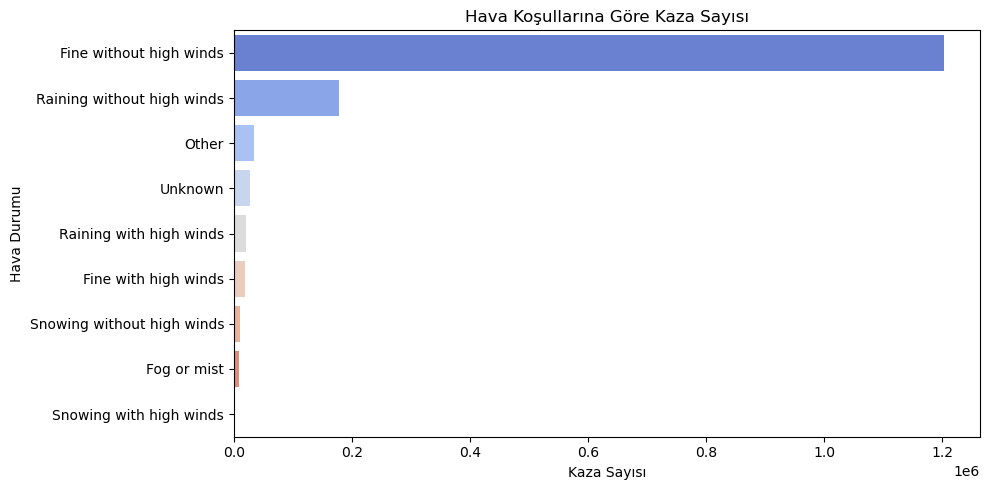

In [55]:
# Hava durumunun kazalara etkisi

df_weather = df[df['Weather_Conditions'].notna()] # calculate missing values count

accident_count = df_weather['Weather_Conditions'].value_counts().sort_values(ascending=False) # calculate accident count according to weather condition

plt.figure(figsize=(10, 5))
sns.barplot(x=accident_count.values, y=accident_count.index, palette="coolwarm")
plt.title("Hava Koşullarına Göre Kaza Sayısı")
plt.xlabel("Kaza Sayısı")
plt.ylabel("Hava Durumu")
plt.tight_layout()
plt.show()


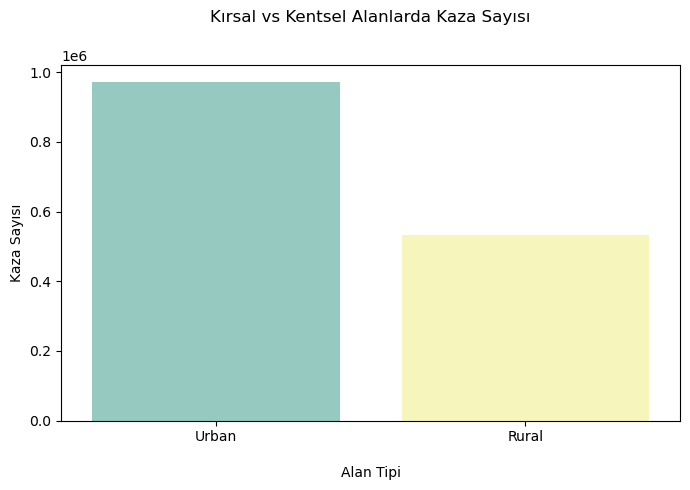

In [65]:
# Arazi türünün kazalara etkisi

df_area = df[df['Urban_or_Rural_Area'].notna()] # calculate missing values count

labels = {
    1: 'Urban',
    2: 'Rural'
}

df_area['Area_Type'] = df_area['Urban_or_Rural_Area'].map(labels)

area_counts = df_area['Area_Type'].value_counts() # calculate te count according to area type

plt.figure(figsize=(7, 5))
sns.barplot(x=area_counts.index, y=area_counts.values, palette="Set3")
plt.title("Kırsal vs Kentsel Alanlarda Kaza Sayısı\n\n")
plt.xlabel("\nAlan Tipi")
plt.ylabel("Kaza Sayısı")
plt.tight_layout()
plt.show()